# DeepLOB in PyTorch — FI-2010 (Setup 2) and LSE, k = 10 / 20 / 50, with the paper's trading simulation

Reproduction of **Zhang, Zohren & Roberts (2019), *"DeepLOB: Deep Convolutional Neural Networks for Limit Order Books"***,
IEEE Trans. Signal Processing, 67(11), 3001–3012.

This notebook implements **exactly** the architecture, loss and optimiser described in the paper (Section IV/V):

- **Input**: the last **T = 100** LOB updates, each a **10-level × 4-feature** snapshot
  (`{ask price, ask volume, bid price, bid volume}` for levels 1..10) → a single input tensor of shape `(100, 40)`.
- **Architecture**: 3 convolutional blocks → Inception module → LSTM(64) → Dense(3) + softmax.
- **Loss**: categorical cross-entropy.
- **Optimiser**: Adam, `lr = 0.01`, `epsilon = 1` (as stated in the paper), batch size **32**,
  early stopping when validation accuracy does not improve for **20** epochs (paper: "about 100 epochs for FI-2010").

**What is run** — every experiment is done for **DeepLOB *and* a multinomial logistic-regression baseline**, at the prediction horizons **k = 10, 20 and 50**:

| Part | Content |
|---|---|
| I, §1–11 | FI-2010, Setup 2 (first 7 days train/val, last 3 days test): accuracy / precision / recall / F1, confusion matrices (Table II analogue), DeepLOB vs. baseline |
| I, §12–13 | **Trading simulation on FI-2010** (paper Section V-D): boxplots of normalised daily profit + t-statistics (Fig. 7 analogue), cumulative profit (Fig. 8 analogue), extra trading metrics, execution-delay sensitivity |
| II, §14–23 | London Stock Exchange experiment (paper Section V-C): Table IV, Fig. 5, Fig. 6 analogues, transfer learning to unseen stocks |
| II, §24 | **Trading simulation on the LSE** (Fig. 7 / Fig. 8 analogues) |

The notebook runs on **GPU automatically if available, and falls back to CPU otherwise.** A few
deliberate engineering choices (in-memory tensor loader, AMP, cuDNN autotune, gradient clipping — see
the "Fast training" cell) speed up training without changing the architecture/loss/optimiser above.

> **Correction w.r.t. the previous version of this notebook:** the FI-2010 label convention is **1 = up, 2 = stationary, 3 = down**
> (verified on the data: label 1 is followed by price rises, label 3 by price falls). The earlier text said the opposite, so the
> "Down"/"Up" names in the reports and confusion matrices were swapped. Labels are now re-coded to **0 = down, 1 = stationary, 2 = up**
> (same as in Part II). Accuracy/F1 values are unaffected; class names and — crucially — the direction of trades are now right.

## 1. Setup

In [ ]:
import os, time, json, zipfile, urllib.request, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True   # inputs are a fixed shape -> let cuDNN autotune

Using device: cuda
Tesla T4


## 2. Experiment configuration

`T`, `BATCH_SIZE`, `LR`, `ADAM_EPS`, `MAX_EPOCHS` and `PATIENCE` are exactly the values reported in the paper
(Section III.C and V.A). `GRAD_CLIP` is **not** in the paper — `lr=0.01` with Adam is high, and clipping the
gradient norm is the one addition needed to keep training numerically stable at that learning rate; everything
else follows the text literally.

### Which FI-2010 label column is which horizon?
The FI-2010 benchmark ships 5 pre-computed label columns, in the fixed order **k = 10, 20, 30, 50, 100**.
`HORIZONS = [10, 20, 50]` (the horizons of Table II of the paper) therefore uses label columns **0, 1 and 3**
(`FI_LABEL_COL`). One separate DeepLOB and one separate baseline model is trained per horizon.

### Trading parameters (paper Section V-D)
`TRADE_DELAY = 5`: a signal produced at time *t* is executed at *t + 5* ("taking slippage into account").

In [ ]:
QUICK_TEST = False   # set True to sanity-check the whole pipeline in a few minutes on a tiny subset

T            = 100     # input window length (paper: "we use the 100 most recent states of the LOB")
HORIZONS     = [10, 20, 50]                               # prediction horizons used everywhere in this notebook
FI_LABEL_COL = {10: 0, 20: 1, 30: 2, 50: 3, 100: 4}       # FI-2010 ships labels for k = 10, 20, 30, 50, 100 (in this order)
NUM_CLASSES  = 3

BATCH_SIZE   = 32       # paper: "we train with mini-batches of size 32"
LR           = 0.01     # paper: "the learning rate to 0.01"
ADAM_EPS     = 1.0      # paper: "we set the parameter epsilon to 1"
MAX_EPOCHS   = 100      # paper: "about 100 epochs for the FI-2010 dataset"
PATIENCE     = 20       # paper: "stopped when validation accuracy does not improve for 20 more epochs"
GRAD_CLIP    = 1.0      # stability aid at lr=0.01 (not specified in the paper)
USE_COMPILE  = True     # torch.compile on CUDA (speed only); set False if you hit compile problems
REUSE_SAVED_FI = True   # re-use saved FI-2010 DeepLOB predictions (fi_deeplob_k*.npz) if present (handy after a Colab disconnect)

# ---- trading simulation (paper Section V-D) ----
TRADE_DELAY           = 5                # signal at t is executed at t+5 (slippage)
FI_SENSITIVITY_DELAYS = [0, 1, 2, 5]     # extra: how sensitive are the FI-2010 results to the execution delay?

DATA_DIR = "fi2010_data"

## 3. FI-2010 data

We use the **Decimal-Precision, no-auction, Setup-2** split of FI-2010 exactly as released by the DeepLOB
authors themselves (`Train_Dst_NoAuction_DecPre_CF_7.txt` = first 7 days, `Test_Dst_NoAuction_DecPre_CF_{7,8,9}.txt`
= last 3 days). This is the identical file set used in the authors' own reference PyTorch notebook. The paper
notes the reported results are not sensitive to which of the 3 provided normalisations (z-score / min-max /
decimal-precision) is used; if you prefer the z-score version instead, download it from the official archive
(https://etsin.fairdata.fi/dataset/73eb48d7-4dbc-4a10-a52a-da745b47a649) and point `DATA_DIR` at it — the rest
of the notebook is unaffected (for the trading simulation the DecPre files are convenient because prices stay proportional to real prices).

**Format** (149 rows × N columns, columns = consecutive LOB snapshots; every column is itself a block of 10 raw events):
- rows 0–39: the 40 LOB features, 10 levels × `{ask price, ask volume, bid price, bid volume}`
- rows 40–143: extra hand-crafted features from Kercheval & Zhang (2015) — **not used** by DeepLOB
- rows 144–148 (last 5 rows): labels ∈ {1, 2, 3} for horizons k = 10, 20, 30, 50, 100 respectively.
  **Dataset convention: 1 = up, 2 = stationary, 3 = down.** We re-code them to 0 = down, 1 = stationary, 2 = up.

**Day / stock structure (needed for the trading simulation).** Each of the 3 test files is one trading day (days 8, 9, 10)
and contains the **5 stocks back-to-back**. The boundary between two stocks is unmistakable in the mid-price (a jump of > 25 %, whereas
ordinary moves are < 1 %), so we detect it with a 5 % threshold. Each *(stock, day)* pair is one trading session in §12–13.

In [ ]:
def download_fi2010(data_dir=DATA_DIR):

    os.makedirs(data_dir, exist_ok=True)

    files = ["Train_Dst_NoAuction_DecPre_CF_7.txt",

             "Test_Dst_NoAuction_DecPre_CF_7.txt",

             "Test_Dst_NoAuction_DecPre_CF_8.txt",

             "Test_Dst_NoAuction_DecPre_CF_9.txt"]

    if all(os.path.isfile(os.path.join(data_dir, f)) for f in files):

        print("FI-2010 data already present.")

        return

    url = ("https://raw.githubusercontent.com/zcakhaa/"

           "DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/"

           "master/data/data.zip")

    zip_path = os.path.join(data_dir, "data.zip")

    print("Downloading FI-2010 (Decimal-Precision, no-auction, Setup 2) data ...")

    urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path) as zf:

        zf.extractall(data_dir)

    os.remove(zip_path)

    print("Done.")



download_fi2010()

Done.


In [ ]:
print("Loading raw FI-2010 text files (this can take ~30-90s)...")
train_full = np.loadtxt(os.path.join(DATA_DIR, "Train_Dst_NoAuction_DecPre_CF_7.txt"))

# the 3 test files = days 8, 9, 10 (kept separate so that we know where each trading day starts and ends)
FI_TEST_DAY_NAMES = ["Day 8", "Day 9", "Day 10"]
test_day_raw = [np.loadtxt(os.path.join(DATA_DIR, f"Test_Dst_NoAuction_DecPre_CF_{d}.txt")) for d in (7, 8, 9)]

# 80/20 split of the 7 training days into train / validation, exactly as in the paper's
# protocol ("we carefully optimise any hyper-parameter on a separate validation set
# before moving to the out-of-sample test set").
split = int(np.floor(train_full.shape[1] * 0.8))
train_raw = train_full[:, :split]
val_raw   = train_full[:, split:]

if QUICK_TEST:
    train_raw = train_raw[:, :5000]
    val_raw   = val_raw[:, :2000]
    test_day_raw = [d[:, :2000] for d in test_day_raw]

test_full = np.hstack(test_day_raw)


def stock_segments(raw_day, jump=0.05):
    """Index (0,1,2,...) of the stock each column of a day-file belongs to: a new stock starts wherever the level-1 mid-price
    jumps by more than `jump` (5 %) from one column to the next (ordinary moves are < 1 %)."""
    mid = 0.5 * (raw_day[0] + raw_day[2])
    rel = np.abs(np.diff(mid)) / mid[:-1]
    return np.concatenate([[0], np.cumsum(rel > jump)]).astype(np.int64)


test_day_col   = np.concatenate([np.full(d.shape[1], i) for i, d in enumerate(test_day_raw)])   # which test day each column is in
test_stock_col = np.concatenate([stock_segments(d) for d in test_day_raw])                      # which stock (0..4) within that day
test_mid       = 0.5 * (test_full[0] + test_full[2])                                            # level-1 mid-price (DecPre units)
for i, d in enumerate(test_day_raw):
    seg = np.bincount(test_stock_col[test_day_col == i])
    print(f"{FI_TEST_DAY_NAMES[i]}: {d.shape[1]} columns, {len(seg)} stocks, columns per stock = {seg.tolist()}")
    if not QUICK_TEST and len(seg) != 5:
        print("  WARNING: expected 5 stocks per day - check the stock-boundary detection (`jump`).")
del test_day_raw

print("train cols:", train_raw.shape, "val cols:", val_raw.shape, "test cols:", test_full.shape)

Loading raw FI-2010 text files (this can take ~30-90s)...
Day 8: 55478 columns, 5 stocks, columns per stock = [2647, 8662, 8591, 13229, 22349]
Day 9: 52172 columns, 5 stocks, columns per stock = [1873, 9271, 10036, 12880, 18112]
Day 10: 31937 columns, 5 stocks, columns per stock = [1888, 5128, 5722, 5821, 13378]
train cols: (149, 203800) val cols: (149, 50950) test cols: (149, 139587)


## 4. Build the (100 × 40) sliding-window dataset

Each input `X[i]` is exactly the `X = [x1, ..., x100]^T ∈ R^(100×40)` matrix of Eq. (6)/Section III.C:
the 100 most recent LOB snapshots, each snapshot being the 40 raw `{price, volume}` values across
the 10 bid/ask levels. The windows do not depend on the horizon, so they are built **once**; the label attached to
window `i` is the FI-2010 label of its **last** row, and we keep the labels of **all 5 horizons** (`y_all`, shape `(N, 5)`;
pick the column with `FI_LABEL_COL[k]`).

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

def prepare_x(raw):
    """rows 0..39 (the 40 raw LOB features) -> (N, 40) float32"""
    return raw[:40, :].T.astype(np.float32)

def get_labels(raw):
    """last 5 rows (labels for k=10,20,30,50,100) -> (N, 5) int64.
    Dataset convention is 1 = up, 2 = stationary, 3 = down; re-coded here to 0 = down, 1 = stationary, 2 = up."""
    return 3 - raw[-5:, :].T.astype(np.int64)

def make_windows(raw, T):
    """-> windows (N-T+1, T, 40) float32 and the labels of all 5 horizons (N-T+1, 5), aligned with the window's LAST row"""
    X = prepare_x(raw)                                        # (N, 40)
    Y = get_labels(raw)                                       # (N, 5)
    N, D = X.shape
    Xw = np.ascontiguousarray(sliding_window_view(X, (T, D))[:, 0])
    return Xw, Y[T - 1:N]

print("Building sliding windows (T=100) ...")
X_train, Y_train_all = make_windows(train_raw, T)
X_val,   Y_val_all   = make_windows(val_raw,   T)
X_test,  Y_test_all  = make_windows(test_full, T)
print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)
for k in HORIZONS:
    c = FI_LABEL_COL[k]
    print(f"k={k:3d} class balance (down/stat/up)  train: {np.round(np.bincount(Y_train_all[:, c], minlength=3) / len(Y_train_all), 3)}"
          f"  test: {np.round(np.bincount(Y_test_all[:, c], minlength=3) / len(Y_test_all), 3)}")

Building sliding windows (T=100) ...
train: (203701, 100, 40) val: (50851, 100, 40) test: (139488, 100, 40)
k= 10 class balance (down/stat/up)  train: [0.201 0.598 0.201]  test: [0.142 0.707 0.151]
k= 20 class balance (down/stat/up)  train: [0.256 0.486 0.258]  test: [0.183 0.621 0.197]
k= 50 class balance (down/stat/up)  train: [0.346 0.303 0.351]  test: [0.252 0.473 0.275]


## 5. Fast, GPU-resident data loading

This is the main speed optimisation in the notebook (architecture/loss/optimiser above are untouched).
The whole precomputed window tensor comfortably fits in RAM (and usually in GPU memory too), so instead of a
`torch.utils.data.DataLoader` with worker processes and per-batch CPU→GPU copies, `WindowStore` keeps
the windows resident on the training device **once** (they are shared by all three horizons — only the labels differ), and
`FastTensorLoader` yields mini-batches by pure indexing. On GPU this removes
essentially all data-loading overhead; on CPU it's just simple, fast slicing.

In [ ]:
class WindowStore:
    """One (N, 1, T, 40) float32 tensor of windows, kept on `device` if it fits (shared by all horizons)."""

    def __init__(self, X, device):
        self.X = torch.from_numpy(X).unsqueeze(1)          # (N, 1, T, 40)
        self.device = device
        self.on_device = False
        try:
            if device.type == "cuda":
                free_mem, _ = torch.cuda.mem_get_info()
                need = self.X.element_size() * self.X.nelement()
                if need < 0.6 * free_mem:
                    self.X = self.X.to(device)
                    self.on_device = True
        except Exception:
            pass

    @property
    def n(self):
        return self.X.shape[0]


class FastTensorLoader:
    """Yields mini-batches of a WindowStore (+ the labels of one horizon) by indexing, avoiding DataLoader
    worker/collate/pin-memory overhead for datasets that fit in memory."""

    def __init__(self, store, y, batch_size, shuffle=True):
        self.store = store
        self.y = torch.from_numpy(np.ascontiguousarray(y, dtype=np.int64))
        if store.on_device:
            self.y = self.y.to(store.device)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n = store.n

    def __len__(self):
        return (self.n + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        idx = torch.randperm(self.n) if self.shuffle else torch.arange(self.n)
        for start in range(0, self.n, self.batch_size):
            b = idx[start:start + self.batch_size]
            xb, yb = self.store.X[b], self.y[b]
            if not self.store.on_device:
                xb = xb.to(self.store.device, non_blocking=True)
                yb = yb.to(self.store.device, non_blocking=True)
            yield xb.float(), yb.long()


train_store = WindowStore(X_train, DEVICE)
val_store   = WindowStore(X_val,   DEVICE)
test_store  = WindowStore(X_test,  DEVICE)
print(f"On-device caching -> train: {train_store.on_device}, val: {val_store.on_device}, test: {test_store.on_device}")


def make_loaders(k):
    """train / val / test loaders for horizon k (same windows, different label column)"""
    c = FI_LABEL_COL[k]
    return (FastTensorLoader(train_store, Y_train_all[:, c], BATCH_SIZE, shuffle=True),
            FastTensorLoader(val_store,   Y_val_all[:, c],   BATCH_SIZE, shuffle=False),
            FastTensorLoader(test_store,  Y_test_all[:, c],  BATCH_SIZE, shuffle=False))

_l = make_loaders(HORIZONS[0])
print(f"Batches/epoch -> train: {len(_l[0])}, val: {len(_l[1])}, test: {len(_l[2])}")
del _l

On-device caching -> train: True, val: True, test: True
Batches/epoch -> train: 6366, val: 1590, test: 4359


## 6. DeepLOB architecture (Section IV of the paper)



Exactly as in Fig. 3 / Fig. 4:

- **Conv block 1**: `Conv(1×2, stride 1×2)` (merges price/volume per level) → `Conv(4×1)` → `Conv(4×1)`

- **Conv block 2**: `Conv(1×2, stride 1×2)` (merges pairs of levels, forms a "micro-price"-like feature) → `Conv(4×1)` → `Conv(4×1)`

- **Conv block 3**: `Conv(1×10)` (merges across all remaining levels) → `Conv(4×1)` → `Conv(4×1)`

- **Inception module**: 3 parallel branches (`1×1→3×1`, `1×1→5×1`, `maxpool→1×1`), each with 64 filters, concatenated

- **LSTM(64)** over the resulting 100 time steps, taking the last hidden state

- **Dense(3) + softmax** (implemented as raw logits; softmax is folded into `CrossEntropyLoss`)



Leaky-ReLU (`negative_slope=0.01`, as in the paper) is used everywhere except conv block 2, and batch

normalisation follows every conv layer, matching the authors' own reference implementation.

In [ ]:
class DeepLOB(nn.Module):

    def __init__(self, num_classes=3):

        super().__init__()



        self.conv1 = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=(1, 2), stride=(1, 2)),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(32),

        )

        self.conv2 = nn.Sequential(

            nn.Conv2d(32, 32, kernel_size=(1, 2), stride=(1, 2)),

            nn.Tanh(),

            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),

            nn.Tanh(),

            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),

            nn.Tanh(),

            nn.BatchNorm2d(32),

        )

        self.conv3 = nn.Sequential(

            nn.Conv2d(32, 32, kernel_size=(1, 10)),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(32),

        )



        # Inception module (Fig. 4): 3 parallel branches, 64 filters each

        self.inp1 = nn.Sequential(

            nn.Conv2d(32, 64, kernel_size=(1, 1), padding="same"),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=(3, 1), padding="same"),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(64),

        )

        self.inp2 = nn.Sequential(

            nn.Conv2d(32, 64, kernel_size=(1, 1), padding="same"),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=(5, 1), padding="same"),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(64),

        )

        self.inp3 = nn.Sequential(

            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),

            nn.Conv2d(32, 64, kernel_size=(1, 1), padding="same"),

            nn.LeakyReLU(negative_slope=0.01),

            nn.BatchNorm2d(64),

        )



        # 3 branches x 64 filters = 192 features per time step, fed to the LSTM

        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)

        self.fc = nn.Linear(64, num_classes)



    def forward(self, x):

        # x: (batch, 1, 100, 40)

        x = self.conv1(x)

        x = self.conv2(x)

        x = self.conv3(x)                                   # -> (batch, 32, 100, 1)



        x1 = self.inp1(x)

        x2 = self.inp2(x)

        x3 = self.inp3(x)

        x = torch.cat([x1, x2, x3], dim=1)                   # -> (batch, 192, 100, 1)



        x = x.permute(0, 2, 1, 3)                            # -> (batch, 100, 192, 1)

        x = x.reshape(x.shape[0], x.shape[1], -1)            # -> (batch, 100, 192)



        x, _ = self.lstm(x)

        x = x[:, -1, :]                                      # last time step's hidden state

        return self.fc(x)                                    # logits; softmax folded into CrossEntropyLoss

In [ ]:
_net = DeepLOB(num_classes=NUM_CLASSES)
n_params = sum(p.numel() for p in _net.parameters())
print(_net)
print(f"\nTotal trainable parameters: {n_params:,}")
del _net
# The paper notes DeepLOB has an order of magnitude fewer parameters than CNN-I because it uses an
# LSTM instead of fully-connected layers on top of the conv features (Table III).

DeepLOB(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(1, 2), stride=(1, 2))
    (1): LeakyReLU(negative_slope=0.01)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(4, 1), stride=(1, 1))
    (4): LeakyReLU(negative_slope=0.01)
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(32, 32, kernel_size=(4, 1), stride=(1, 1))
    (7): LeakyReLU(negative_slope=0.01)
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(1, 2), stride=(1, 2))
    (1): Tanh()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(4, 1), stride=(1, 1))
    (4): Tanh()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(32, 32, kernel_size=(4, 1), stride

## 7. Loss, optimiser (as stated in the paper)

In [ ]:
criterion = nn.CrossEntropyLoss()
use_amp = (DEVICE.type == "cuda")   # mixed precision only helps (and is only safe) on CUDA


def unwrap(net):
    """the underlying nn.Module (undoes torch.compile) - handy for saving clean state dicts"""
    return getattr(net, "_orig_mod", net)


def build_model():
    """a freshly initialised DeepLOB on DEVICE (one is trained per horizon); optional speed-up via torch.compile"""
    net = DeepLOB(num_classes=NUM_CLASSES).to(DEVICE)
    if USE_COMPILE and DEVICE.type == "cuda":
        try:
            net = torch.compile(net)
        except Exception as e:
            print(f"torch.compile not used ({e}).")
    return net

# The optimiser (Adam, lr=0.01, eps=1 as in the paper) and the AMP GradScaler are created fresh for every model inside train_deeplob().

## 8. Training loop (Adam, batch 32, early stopping on validation accuracy)

One DeepLOB is trained **per horizon** (k = 10, 20, 50), each from a fresh initialisation with the same seed. The best-validation-accuracy weights
are restored before testing. Predictions are cached to `fi_deeplob_k*.npz` (and weights saved to `deeplob_fi2010_k*.pth`).

In [ ]:
@torch.no_grad()
def evaluate(net, loader):
    net.eval()
    losses = []
    all_preds, all_targets = [], []
    for xb, yb in loader:
        with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
            out = net(xb)
            loss = criterion(out, yb)
        losses.append(loss.item())
        all_preds.append(out.argmax(1).cpu())
        all_targets.append(yb.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    acc = accuracy_score(all_targets, all_preds)
    return float(np.mean(losses)), acc, all_preds, all_targets


def train_deeplob(net, train_loader, val_loader, tag="", max_epochs=MAX_EPOCHS, patience=PATIENCE):
    optimizer = torch.optim.Adam(net.parameters(), lr=LR, eps=ADAM_EPS)
    scaler = torch.amp.GradScaler(enabled=use_amp)
    best_val_acc = -1.0
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, max_epochs + 1):
        net.train()
        t0 = time.time()
        train_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                out = net(xb)
                loss = criterion(out, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss, val_acc, _, _ = evaluate(net, val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        dt = time.time() - t0
        print(f"[{tag}] Epoch {epoch:3d}/{max_epochs} | train_loss {train_loss:.4f} | "
              f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f} "
              f"{'*' if improved else ' '} | {dt:5.1f}s")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping: validation accuracy hasn't improved for {patience} epochs.")
            break

    if best_state is not None:
        net.load_state_dict(best_state)
    return history

In [11]:
fi_history, fi_pred_deeplob, fi_true = {}, {}, {}      # keyed by horizon k


def _fi_cache(k):
    return f"fi_deeplob_k{k}{'_quick' if QUICK_TEST else ''}.npz"


for k in HORIZONS:
    cache = _fi_cache(k)
    if REUSE_SAVED_FI and os.path.isfile(cache):
        z = np.load(cache)
        if len(z["pred"]) == len(Y_test_all):
            fi_pred_deeplob[k], fi_true[k] = z["pred"], z["true"]
            fi_history[k] = {n: list(z[n]) for n in ("train_loss", "val_loss", "val_acc")}
            print(f"k={k}: loaded saved DeepLOB predictions from {cache}  (set REUSE_SAVED_FI = False to retrain)")
            continue

    print(f"\n{'=' * 28}  DeepLOB on FI-2010, k = {k}  {'=' * 28}")
    torch.manual_seed(SEED)
    train_loader, val_loader, test_loader = make_loaders(k)
    net = build_model()
    fi_history[k] = train_deeplob(net, train_loader, val_loader, tag=f"k={k}")
    torch.save(unwrap(net).state_dict(), f"deeplob_fi2010_k{k}.pth")
    _, acc, yp, yt = evaluate(net, test_loader)
    fi_pred_deeplob[k], fi_true[k] = yp, yt
    np.savez(cache, pred=yp, true=yt, **{n: np.array(v) for n, v in fi_history[k].items()})
    print(f"k={k}: DeepLOB test accuracy {acc:.4f}  (model saved to deeplob_fi2010_k{k}.pth)")
    del net, train_loader, val_loader, test_loader
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


============================  DeepLOB on FI-2010, k = 10  ============================


W1001 09:13:32.076000 1164 torch/_inductor/utils.py:1731] [0/0_1] Not enough SMs to use max_autotune_gemm mode


[k=10] Epoch   1/100 | train_loss 0.9413 | val_loss 0.9115 | val_acc 0.6338 * | 191.1s
[k=10] Epoch   2/100 | train_loss 0.9298 | val_loss 0.9123 | val_acc 0.6338   |  88.1s
[k=10] Epoch   3/100 | train_loss 0.8579 | val_loss 0.9518 | val_acc 0.6338   |  87.9s
[k=10] Epoch   4/100 | train_loss 0.7478 | val_loss 0.8477 | val_acc 0.6536 * |  87.7s
[k=10] Epoch   5/100 | train_loss 0.7247 | val_loss 0.9889 | val_acc 0.6557 * |  87.0s
[k=10] Epoch   6/100 | train_loss 0.7173 | val_loss 0.8328 | val_acc 0.6339   |  87.3s
[k=10] Epoch   7/100 | train_loss 0.7172 | val_loss 0.7591 | val_acc 0.6709 * |  87.3s
[k=10] Epoch   8/100 | train_loss 0.7144 | val_loss 0.7839 | val_acc 0.6596   |  88.0s
[k=10] Epoch   9/100 | train_loss 0.7134 | val_loss 0.7866 | val_acc 0.6564   |  87.7s
[k=10] Epoch  10/100 | train_loss 0.7029 | val_loss 0.7551 | val_acc 0.6689   |  87.9s
[k=10] Epoch  11/100 | train_loss 0.6940 | val_loss 1.1068 | val_acc 0.4139   |  88.8s
[k=10] Epoch  12/100 | train_loss 0.6599 | 

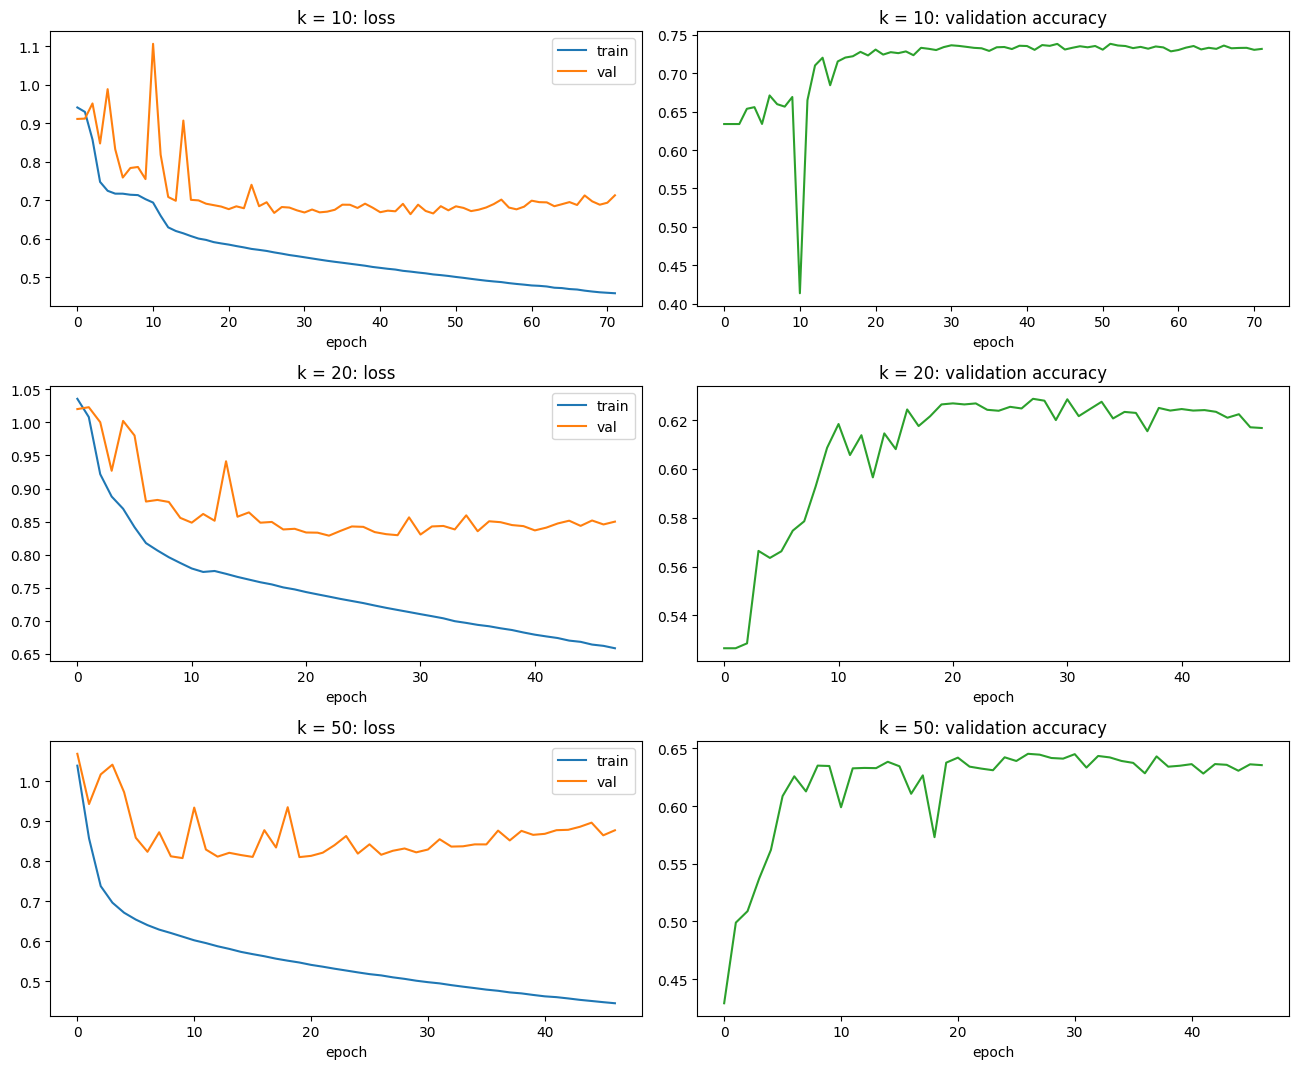

In [12]:
fig, axes = plt.subplots(len(HORIZONS), 2, figsize=(13, 3.6 * len(HORIZONS)), squeeze=False)
for r, k in enumerate(HORIZONS):
    h = fi_history[k]
    axes[r, 0].plot(h["train_loss"], label="train")
    axes[r, 0].plot(h["val_loss"], label="val")
    axes[r, 0].set_title(f"k = {k}: loss"); axes[r, 0].set_xlabel("epoch"); axes[r, 0].legend()
    axes[r, 1].plot(h["val_acc"], color="tab:green")
    axes[r, 1].set_title(f"k = {k}: validation accuracy"); axes[r, 1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 9. Test-set evaluation (last 3 days, k = 10, 20, 50)

Both **macro** averages (as in the previous version of this notebook) and **support-weighted** averages are reported. The paper's Table II has
Recall = Accuracy for DeepLOB, which only happens with *weighted* averaging, so the weighted columns are the ones to compare with the paper.

In [13]:
# Paper, Table II (Setup 2), DeepLOB row, in %
PAPER_TABLE_II = {10: {"Accuracy": 84.47, "Precision": 84.00, "Recall": 84.47, "F1": 83.40},
                  20: {"Accuracy": 74.85, "Precision": 74.06, "Recall": 74.85, "F1": 72.82},
                  50: {"Accuracy": 80.51, "Precision": 80.38, "Recall": 80.51, "F1": 80.35}}
CLASS_NAMES = ["Down", "Stationary", "Up"]


def clf_metrics(y, p):
    pm, rm, fm, _ = precision_recall_fscore_support(y, p, average="macro", zero_division=0)
    pw, rw, fw, _ = precision_recall_fscore_support(y, p, average="weighted", zero_division=0)
    return {"Accuracy": accuracy_score(y, p),
            "Precision (macro)": pm, "Recall (macro)": rm, "F1 (macro)": fm,
            "Precision (weighted)": pw, "Recall (weighted)": rw, "F1 (weighted)": fw}


for k in HORIZONS:
    print(f"\n================  DeepLOB, FI-2010 Setup 2, k = {k}  ================")
    print(classification_report(fi_true[k], fi_pred_deeplob[k], digits=4, target_names=CLASS_NAMES))

deeplob_fi_metrics = pd.DataFrame({k: clf_metrics(fi_true[k], fi_pred_deeplob[k]) for k in HORIZONS}).T
deeplob_fi_metrics.index.name = "k"
print("DeepLOB - test metrics (fractions)")
display(deeplob_fi_metrics.round(4))

w = 100 * deeplob_fi_metrics[["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 (weighted)"]]
w.columns = ["Accuracy %", "Precision %", "Recall %", "F1 %"]
paper_df = pd.DataFrame(PAPER_TABLE_II).T.rename(columns=lambda c: c + " %")
paper_df.index.name = "k"
print("\nThis run (weighted averages) vs. paper Table II (DeepLOB, Setup 2):")
display(pd.concat({"this run": w, "paper": paper_df}, axis=1).round(2))


================  DeepLOB, FI-2010 Setup 2, k = 10  ================
              precision    recall  f1-score   support

        Down     0.7018    0.5186    0.5965     19759
  Stationary     0.8505    0.9419    0.8939     98602
          Up     0.7025    0.5215    0.5986     21127

    accuracy                         0.8183    139488
   macro avg     0.7516    0.6607    0.6963    139488
weighted avg     0.8070    0.8183    0.8070    139488


================  DeepLOB, FI-2010 Setup 2, k = 20  ================
              precision    recall  f1-score   support

        Down     0.5955    0.4442    0.5088     25475
  Stationary     0.7685    0.9133    0.8347     86588
          Up     0.6437    0.4125    0.5028     27425

    accuracy                         0.7292    139488
   macro avg     0.6692    0.5900    0.6154    139488
weighted avg     0.7123    0.7292    0.7099    139488


================  DeepLOB, FI-2010 Setup 2, k = 50  ================
              precision    r

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted)
k,,,,,,,
10,0.8183,0.7516,0.6607,0.6963,0.8070,0.8183,0.8070
20,0.7292,0.6692,0.5900,0.6154,0.7123,0.7292,0.7099
50,0.7566,0.7374,0.7346,0.7359,0.7554,0.7566,0.7559



This run (weighted averages) vs. paper Table II (DeepLOB, Setup 2):


this run                                  paper                       \
   Accuracy % Precision % Recall %   F1 % Accuracy % Precision % Recall %   
k                                                                           
10      81.83       80.70    81.83  80.70      84.47       84.00    84.47   
20      72.92       71.23    72.92  70.99      74.85       74.06    74.85   
50      75.66       75.54    75.66  75.59      80.51       80.38    80.51   

           
     F1 %  
k          
10  83.40  
20  72.82  
50  80.35

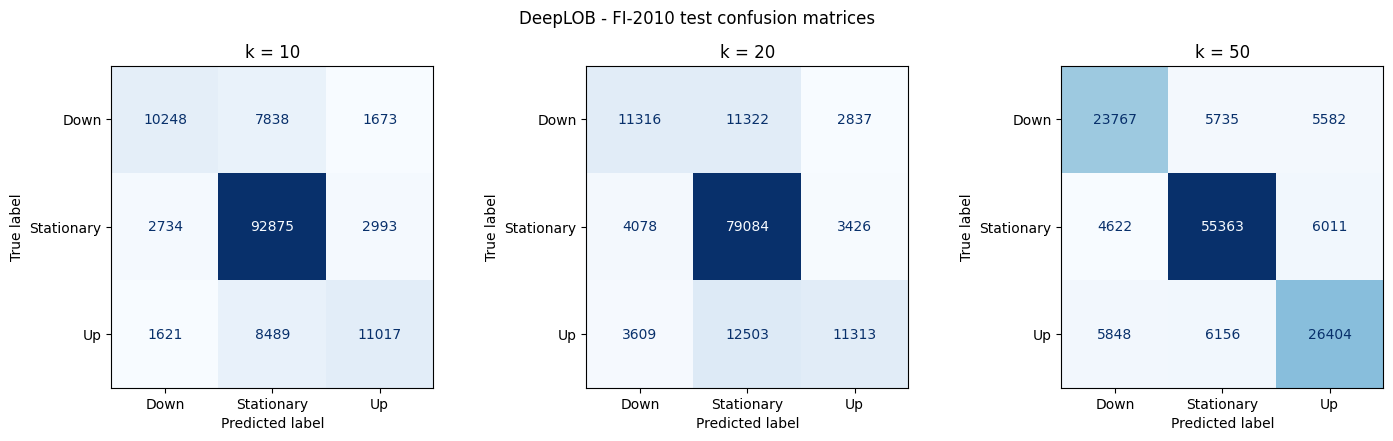

In [14]:
def plot_fi_confusions(preds, model_name):
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(4.8 * len(HORIZONS), 4.4), squeeze=False)
    for ax, k in zip(axes[0], HORIZONS):
        ConfusionMatrixDisplay(confusion_matrix(fi_true[k], preds[k], labels=[0, 1, 2]),
                               display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
        ax.set_title(f"k = {k}")
    fig.suptitle(f"{model_name} - FI-2010 test confusion matrices")
    plt.tight_layout(); plt.show()

plot_fi_confusions(fi_pred_deeplob, "DeepLOB")

## 10. Baseline: multinomial logistic regression

Same inputs as DeepLOB (the identical `(100, 40)` windows, flattened to a 4000-dim vector), same 3 classes,
trained to minimise the same (multinomial) cross-entropy / softmax objective — but with a **linear** model
instead of the CNN + Inception + LSTM stack. This isolates how much of DeepLOB's performance comes from the
architecture rather than from simply having access to a 100-tick window.

We fit it with `SGDClassifier(loss="log_loss")` using mini-batch `partial_fit`, which scales to this many
samples × features far better than a batch solver (`lbfgs`/`saga`) would. One classifier per horizon (k = 10, 20, 50); since the inputs are identical,
all three are trained in the same pass over the data (the standardised mini-batch is computed once and shared).

[LogReg] epoch 1/5 | val_acc k=10: 0.6338  k=20: 0.5265  k=50: 0.3639
[LogReg] epoch 2/5 | val_acc k=10: 0.6338  k=20: 0.5265  k=50: 0.3141
[LogReg] epoch 3/5 | val_acc k=10: 0.6338  k=20: 0.5265  k=50: 0.3721
[LogReg] epoch 4/5 | val_acc k=10: 0.6328  k=20: 0.5266  k=50: 0.3162
[LogReg] epoch 5/5 | val_acc k=10: 0.2172  k=20: 0.2398  k=50: 0.3162

================  Logistic regression, FI-2010 Setup 2, k = 10  ================
              precision    recall  f1-score   support

        Down     0.1635    0.4899    0.2452     19759
  Stationary     0.7327    0.5374    0.6200     98602
          Up     0.3540    0.1333    0.1937     21127

    accuracy                         0.4695    139488
   macro avg     0.4167    0.3869    0.3530    139488
weighted avg     0.5947    0.4695    0.5024    139488


================  Logistic regression, FI-2010 Setup 2, k = 20  ================
              precision    recall  f1-score   support

        Down     0.2021    0.5610    0.2972     25

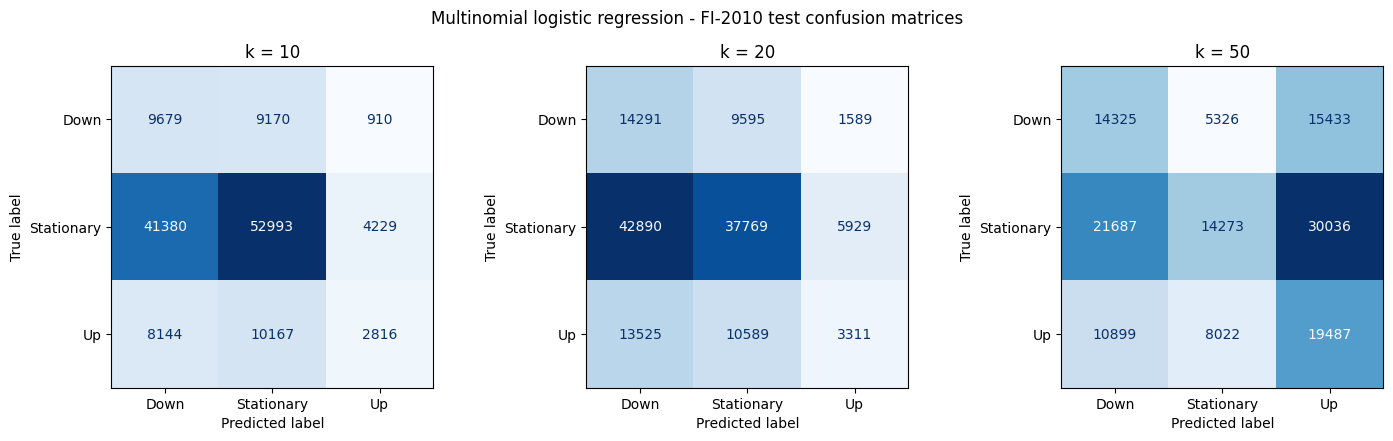

In [15]:
BASELINE_EPOCHS = 5 if not QUICK_TEST else 1
BASELINE_BATCH  = 256
D_FLAT = T * 40

# Fit the scaler incrementally on training data only
scaler_lr = StandardScaler()
for start in range(0, len(X_train), BASELINE_BATCH):
    scaler_lr.partial_fit(X_train[start:start + BASELINE_BATCH].reshape(-1, D_FLAT))


def _std(X, start, stop):
    return scaler_lr.transform(X[start:stop].reshape(-1, D_FLAT)).astype(np.float32)


def predict_logreg(X):
    """predictions of the three baseline classifiers on all windows of X -> {k: (N,) int array}"""
    out = {k: [] for k in HORIZONS}
    for start in range(0, len(X), BASELINE_BATCH):
        xb = _std(X, start, start + BASELINE_BATCH)
        for k in HORIZONS:
            out[k].append(logreg_fi[k].predict(xb))
    return {k: np.concatenate(v) for k, v in out.items()}


# Logistic regression using SGD: one classifier per horizon
logreg_fi = {k: SGDClassifier(loss="log_loss", alpha=1e-5, learning_rate="optimal", random_state=SEED) for k in HORIZONS}
classes = np.array([0, 1, 2])
rng = np.random.RandomState(SEED)
first = True

for ep in range(BASELINE_EPOCHS):
    perm = rng.permutation(len(X_train))
    for start in range(0, len(perm), BASELINE_BATCH):
        idx = perm[start:start + BASELINE_BATCH]
        xb = scaler_lr.transform(X_train[idx].reshape(len(idx), -1)).astype(np.float32)
        for k in HORIZONS:
            yb = Y_train_all[idx, FI_LABEL_COL[k]]
            if first:
                logreg_fi[k].partial_fit(xb, yb, classes=classes)
            else:
                logreg_fi[k].partial_fit(xb, yb)
        first = False
        del xb
    pv = predict_logreg(X_val)
    accs = {k: accuracy_score(Y_val_all[:, FI_LABEL_COL[k]], pv[k]) for k in HORIZONS}
    print(f"[LogReg] epoch {ep + 1}/{BASELINE_EPOCHS} | val_acc " + "  ".join(f"k={k}: {a:.4f}" for k, a in accs.items()))

# Final evaluation on the test days
fi_pred_logreg = predict_logreg(X_test)
for k in HORIZONS:
    assert np.array_equal(fi_true[k], Y_test_all[:, FI_LABEL_COL[k]])       # same test windows / labels as DeepLOB
    print(f"\n================  Logistic regression, FI-2010 Setup 2, k = {k}  ================")
    print(classification_report(fi_true[k], fi_pred_logreg[k], digits=4, target_names=CLASS_NAMES, zero_division=0))

logreg_fi_metrics = pd.DataFrame({k: clf_metrics(fi_true[k], fi_pred_logreg[k]) for k in HORIZONS}).T
logreg_fi_metrics.index.name = "k"
gc.collect()
plot_fi_confusions(fi_pred_logreg, "Multinomial logistic regression")

## 11. DeepLOB vs. multinomial logistic regression (k = 10, 20, 50)

---
## 12. Trading simulation — the rules (paper Section V-D)

The paper closes with *"a simple trading simulation … to test the practicability of our results"*. The rules it states are:

- trade **μ = 1 share** at a time; at each time-step the model's predicted class gives a signal **−1 / 0 / +1 = sell / wait / buy**;
- a **+1 at time *t*** → **buy** at time **t + 5** (taking slippage into account) and **hold until a −1 appears, then sell**; a 0 → do nothing;
  the same rule is applied to **short-selling**; repeat through the day;
- **all positions are closed at the end of the day** (nothing held overnight); no trades during auctions;
- trades are done at the **mid-price, without transaction costs** (gross profit — a relative measure of the predictions' value, not a stand-alone strategy).

**Outputs in the paper:** Fig. 7 — boxplots of the **normalised daily profit (= profit ÷ number of trades that day)** per stock and horizon, plus the **t-statistic**
of a test that these profits are statistically greater than 0 ("essentially the same as Sharpe ratios but more consistent for high-frequency trading");
Fig. 8 — the **cumulative** normalised profit over the test period.

**How the rules are implemented here** (the paper leaves some details open — these are my choices):
1. A *session* is one stock on one day; it starts and ends flat. The signal is computed for every window of the session.
2. Position logic (`_trade_state_machine`): flat + signal → open in that direction; holding + opposite signal → close (a round trip is complete);
   holding + same-direction signal or a 0 → nothing. After closing, the next non-zero signal opens a new position.
3. Orders are filled at the mid-price of event *t + TRADE_DELAY*; orders that would fall after the session end are not sent; leftovers are closed at the last mid-price.
4. A **trade = one completed round trip**; *normalised daily profit = Σ round-trip P&L of the day ÷ number of round trips of the day* (days with no trade are dropped).
5. The **t-statistic** is the one-sided one-sample t-test (H0: mean daily normalised profit ≤ 0) over the test days of a stock (or over all (stock, day) sessions when pooled).
   As an extra, an *a posteriori* per-trade t-statistic (naive: treats all trades as independent) is reported.

Additional metrics reported: trades per day, mean normalised profit (price units **and** basis points of the entry price), hit rate (share of winning trades among non-break-even trades),
long share, average holding time, total profit.

The next cell holds the simulator and the plotting/summary helpers shared by the FI-2010 (§13) and LSE (§24) experiments.

In [ ]:
# ---------------------------------------------------------------------------------------------
# Trading simulation of Section V-D of the paper (shared by the FI-2010 and LSE experiments)
# ---------------------------------------------------------------------------------------------
from scipy import stats
import math

# numba makes the per-event state machine ~100x faster (needed for the multi-million-event LSE test set).
# Without numba the same code still runs as plain Python - fine for FI-2010, slow for the full LSE test set.
try:
    from numba import njit as _njit
    HAVE_NUMBA = True
except Exception:
    HAVE_NUMBA = False
    def _njit(f):
        return f


@_njit
def _trade_state_machine(ends, sig, n, delay):
    """Paper rules, mu = 1 share.  `sig[j]` in {-1, 0, +1} is the signal produced by the window whose last event is
    `ends[j]`.  A non-zero signal is executed `delay` events later at that event's mid-price.
      * flat  + signal s            -> open a position in direction s (+1 = buy/long, -1 = sell/short)
      * long  + (-1) / short + (+1) -> close it (one round-trip trade is complete)
      * same-direction signal while holding, or signal 0 -> do nothing
    Orders that would be executed after the session has closed are never sent; whatever is still open is closed at the
    last mid-price of the session (no overnight positions).  Returns entry idx, exit idx and side of every round trip."""
    m = ends.shape[0]
    entry = np.empty(m, np.int64)
    exit_ = np.empty(m, np.int64)
    side = np.empty(m, np.int64)
    nt = 0
    pos = 0
    cur_entry = 0
    for j in range(m):
        s = sig[j]
        if s == 0:
            continue
        e = ends[j] + delay
        if e > n - 1:
            break
        if pos == 0:
            pos = s
            cur_entry = e
        elif s == -pos:
            entry[nt] = cur_entry
            exit_[nt] = e
            side[nt] = pos
            nt += 1
            pos = 0
    if pos != 0 and cur_entry < n - 1:
        entry[nt] = cur_entry
        exit_[nt] = n - 1
        side[nt] = pos
        nt += 1
    return entry[:nt], exit_[:nt], side[:nt]


def simulate_session(mid, ends, sig, delay=TRADE_DELAY):
    """One trading session (= one stock on one day).
    mid  : (n,)  mid-price at every event of the session (trades are done at mid-price, no costs, as in the paper)
    ends : (m,)  index into `mid` of the last event of each input window (ascending)
    sig  : (m,)  trading signal of each window in {-1, 0, +1} = predicted class - 1 (Down / Stationary / Up)
    Returns per-session aggregates (sums, so that any later normalisation / t-test can be built from them)."""
    mid = np.asarray(mid, dtype=np.float64)
    entry, exit_, side = _trade_state_machine(np.ascontiguousarray(ends, dtype=np.int64),
                                              np.ascontiguousarray(sig, dtype=np.int64), len(mid), int(delay))
    out = dict(n_trades=int(len(entry)), profit=0.0, profit_sq=0.0, bps_sum=0.0, bps_sq=0.0,
               n_win=0, n_loss=0, n_long=0, hold_sum=0.0)
    if len(entry):
        pnl = side * (mid[exit_] - mid[entry])            # profit of each round trip, price units per share
        bps = 1e4 * pnl / mid[entry]                      # same, as a return on the entry price (basis points)
        out.update(profit=float(pnl.sum()), profit_sq=float((pnl ** 2).sum()),
                   bps_sum=float(bps.sum()), bps_sq=float((bps ** 2).sum()),
                   n_win=int((pnl > 0).sum()), n_loss=int((pnl < 0).sum()), n_long=int((side > 0).sum()),
                   hold_sum=float((exit_ - entry).sum()))
    return out


def finalise_trading_frame(df):
    """Adds the paper's 'normalised daily profit' = daily profit / number of trades that day (NaN if no trade)."""
    df = df.copy()
    nt = df["n_trades"].replace(0, np.nan)
    df["norm_profit"] = df["profit"] / nt          # price units (GBX for LSE if prices are in pence)
    df["norm_bps"] = df["bps_sum"] / nt            # basis points of the entry price (comparable across stocks)
    return df


def _tstat(x):
    """One-sided one-sample t-test of H0: mean <= 0 (paper: 'is the profit statistically greater than 0?')."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2 or np.std(x, ddof=1) == 0:
        return np.nan, np.nan
    r = stats.ttest_1samp(x, 0.0, alternative="greater")
    return float(r.statistic), float(r.pvalue)


def trading_summary(df, by=("Model", "k", "Stock"), profit_col="norm_profit"):
    """Trading metrics per group.  The daily t-stat / p-value are computed on `profit_col` (one value per session/day)."""
    by = list(by)
    rows = []
    for key, g in df.groupby(by, sort=False):
        key = key if isinstance(key, tuple) else (key,)
        t_day, p_day = _tstat(g[profit_col])
        n = g["n_trades"].sum()
        if n > 1:
            mb = g["bps_sum"].sum() / n
            vb = max(g["bps_sq"].sum() / n - mb ** 2, 0.0) * n / (n - 1)
            t_trade = mb / math.sqrt(vb / n) if vb > 0 else np.nan
        else:
            t_trade = np.nan
        rows.append({**dict(zip(by, key)),
                     "days": int(g[profit_col].notna().sum()),
                     "trades/day": g["n_trades"].mean(),
                     "mean norm. profit": g["norm_profit"].mean(),
                     "mean norm. profit (bps)": g["norm_bps"].mean(),
                     "t-stat (daily)": t_day,
                     "p (one-sided)": p_day,
                     "t-stat (per trade)": t_trade,
                     "hit rate % (non-flat trades)": (100 * g["n_win"].sum() / (g["n_win"].sum() + g["n_loss"].sum())
                                                     if (g["n_win"].sum() + g["n_loss"].sum()) else np.nan),
                     "long share %": 100 * g["n_long"].sum() / n if n else np.nan,
                     "avg hold (steps)": g["hold_sum"].sum() / n if n else np.nan,
                     "total profit": g["profit"].sum()})
    return pd.DataFrame(rows)


def show_table(df):
    with pd.option_context("display.float_format", "{:,.4g}".format, "display.max_rows", 500,
                           "display.max_columns", 50, "display.width", 250):
        display(df)


# ---- plotting (analogues of Fig. 7 and Fig. 8 of the paper) ---------------------------------------------------------
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
MODEL_COLOURS = {"DeepLOB": "#4C72B0", "Multinomial LogReg": "#DD8452"}


def plot_profit_boxplots(df, model, stock_order, value="norm_profit", ylabel="Normalised daily profit", title="", n_sep=None):
    """Fig. 7 analogue. Top: boxplots of normalised daily profit per stock, one box per horizon k.
    Bottom: t-statistic of those daily profits (H0: mean <= 0) per stock and horizon."""
    sub = df[df["Model"] == model]
    ks = sorted(sub["k"].unique())
    nk = len(ks)
    width = nk + 1
    cols = dict(zip(ks, PALETTE))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(9, 1.3 * len(stock_order) + 3), 7.5), sharex=True,
                                   gridspec_kw=dict(height_ratios=[3, 2]))
    for j, k in enumerate(ks):
        pos, data, tpos, tvals = [], [], [], []
        for i, s in enumerate(stock_order):
            x = sub[(sub["k"] == k) & (sub["Stock"] == s)][value].dropna().values
            p = i * width + j
            if len(x):
                pos.append(p)
                data.append(x)
            tpos.append(p)
            tvals.append(_tstat(x)[0] if len(x) else np.nan)
        if data:
            bp = ax1.boxplot(data, positions=pos, widths=0.8, patch_artist=True, flierprops=dict(marker="o", markersize=3))
            for b in bp["boxes"]:
                b.set_facecolor(cols[k]); b.set_alpha(0.85)
            for m in bp["medians"]:
                m.set_color("k")
        ax2.bar(tpos, np.nan_to_num(np.array(tvals, dtype=float)), width=0.8, color=cols[k])
    for ax in (ax1, ax2):
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.grid(axis="y", alpha=0.3)
        if n_sep:
            ax.axvline(n_sep * width - 1, color="k", lw=0.8, ls=":")
    ax2.set_xticks([i * width + (nk - 1) / 2 for i in range(len(stock_order))])
    ax2.set_xticklabels(stock_order)
    ax2.set_xlabel("Stock")
    ax1.set_ylabel(ylabel)
    ax2.set_ylabel("t-statistic")
    handles = [plt.Rectangle((0, 0), 1, 1, fc=cols[k]) for k in ks]
    ax1.legend(handles, [f"k={k}" for k in ks], loc="best")
    fig.suptitle(title or f"{model} - normalised daily profits and t-statistics (cf. Fig. 7)")
    plt.tight_layout()
    plt.show()


def plot_cumulative_profits(df, model, stock_order, value="norm_profit", ylabel="Cumulative normalised profit", title="", ncols=5):
    """Fig. 8 analogue: cumulative sum of the normalised daily profits over the test days, one panel per stock."""
    sub = df[df["Model"] == model]
    ks = sorted(sub["k"].unique())
    cols = dict(zip(ks, PALETTE))
    nc = min(ncols, len(stock_order))
    nr = math.ceil(len(stock_order) / nc)
    fig, axes = plt.subplots(nr, nc, figsize=(3.5 * nc, 2.9 * nr), squeeze=False)
    for ax, s in zip(axes.ravel(), stock_order):
        for k in ks:
            g = sub[(sub["k"] == k) & (sub["Stock"] == s)].sort_values("DayIdx")
            if len(g):
                ax.plot(g["DayIdx"].values + 1, np.cumsum(g[value].fillna(0).values), color=cols[k],
                        marker="o" if len(g) < 8 else None, ms=3, label=f"k={k}")
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.set_title(s); ax.grid(alpha=0.3); ax.set_xlabel("test day")
    for ax in axes.ravel()[len(stock_order):]:
        ax.axis("off")
    axes.ravel()[0].legend(fontsize=8)
    axes[0, 0].set_ylabel(ylabel)
    fig.suptitle(title or f"{model} - cumulative normalised profit over the test period (cf. Fig. 8)")
    plt.tight_layout()
    plt.show()


def plot_pooled_comparison(df, value="norm_profit", ylabel="Normalised daily profit", title=""):
    """DeepLOB vs baseline, all stocks pooled: boxplots of normalised daily profit and pooled t-statistic per horizon."""
    models = [m for m in MODEL_COLOURS if m in set(df["Model"])]
    ks = sorted(df["k"].unique())
    width = len(models) + 1
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
    for mi, m in enumerate(models):
        pos, data, tv = [], [], []
        for ki, k in enumerate(ks):
            x = df[(df["Model"] == m) & (df["k"] == k)][value].dropna().values
            pos.append(ki * width + mi)
            data.append(x)
            tv.append(_tstat(x)[0] if len(x) else np.nan)
        bp = ax1.boxplot(data, positions=pos, widths=0.8, patch_artist=True, flierprops=dict(marker="o", markersize=3))
        for b in bp["boxes"]:
            b.set_facecolor(MODEL_COLOURS[m]); b.set_alpha(0.85)
        for md in bp["medians"]:
            md.set_color("k")
        ax2.bar(pos, np.nan_to_num(np.array(tv, dtype=float)), width=0.8, color=MODEL_COLOURS[m], label=m)
    for ax in (ax1, ax2):
        ax.axhline(0, color="gray", lw=0.8, ls="--"); ax.grid(axis="y", alpha=0.3)
        ax.set_xticks([ki * width + (len(models) - 1) / 2 for ki in range(len(ks))])
        ax.set_xticklabels([f"k={k}" for k in ks])
    ax1.set_ylabel(ylabel); ax2.set_ylabel("pooled t-statistic (daily profits > 0)")
    ax1.legend([plt.Rectangle((0, 0), 1, 1, fc=MODEL_COLOURS[m]) for m in models], models, loc="best")
    fig.suptitle(title or "DeepLOB vs. logistic-regression baseline in the trading simulation (all stocks pooled)")
    plt.tight_layout()
    plt.show()


## 13. Trading simulation on FI-2010 (Setup 2 test days)

The 3 test days × 5 stocks give **15 trading sessions**. Each is traded with the predictions of §9 (DeepLOB) and §10 (baseline) at every horizon, using the rules of §12,
with `TRADE_DELAY = 5` samples (the paper's literal rule). One FI-2010 sample (column) is a block of 10 raw LOB events; see §13.4 for what that means for the delay.

In [ ]:
FI_STOCKS = [f"S{i + 1}" for i in range(5)]      # the 5 FI-2010 stocks, in the (fixed) order in which they appear in every day file
FI_MODEL_PREDS = {"DeepLOB": fi_pred_deeplob, "Multinomial LogReg": fi_pred_logreg}


def find_sessions(day_col, stock_col):
    """consecutive runs of (day, stock) in the test columns -> list of trading sessions (column ranges)"""
    key = day_col * 10 + stock_col
    cuts = np.r_[0, np.where(np.diff(key) != 0)[0] + 1, len(key)]
    return [dict(day=int(day_col[a]), stock=int(stock_col[a]), start=int(a), stop=int(b)) for a, b in zip(cuts[:-1], cuts[1:])]


fi_sessions = find_sessions(test_day_col, test_stock_col)
print(f"{len(fi_sessions)} trading sessions (stock x day) in the 3 test days")


def run_fi_trading(pred_by_model, delay=TRADE_DELAY):
    """Trade every (stock, day) session of the FI-2010 test set with every model's predictions at every horizon.
    Window j of X_test ends at test column j + T - 1; windows that would reach back into another stock / day are not traded."""
    rows = []
    for s in fi_sessions:
        a, b = s["start"], s["stop"]
        if b - a <= T:
            continue
        ends_glob = np.arange(a + T - 1, b)             # columns at which a full 100-event window lies inside this session
        widx = ends_glob - (T - 1)                      # index of that window in X_test / the prediction arrays
        ends_loc = ends_glob - a                        # position inside the session's mid-price series
        for model, preds in pred_by_model.items():
            for k in HORIZONS:
                signal = preds[k][widx].astype(np.int64) - 1        # class 0/1/2 (down/stat/up) -> sell / wait / buy
                res = simulate_session(test_mid[a:b], ends_loc, signal, delay)
                rows.append(dict(Dataset="FI-2010", Model=model, k=k, Stock=FI_STOCKS[s["stock"]], Group="test",
                                 DayIdx=s["day"], Day=FI_TEST_DAY_NAMES[s["day"]], **res))
    return finalise_trading_frame(pd.DataFrame(rows))


df_fi_trade = run_fi_trading(FI_MODEL_PREDS, TRADE_DELAY)

# FI-2010 prices are decimal-precision scaled, and the 5 stocks have different price levels, so the headline profit unit here is
# basis points of the entry mid-price (`norm_bps`); price-unit profits are in the tables as well.
print(f"Trading results: {len(df_fi_trade)} (model x horizon x stock x day) sessions, TRADE_DELAY = {TRADE_DELAY} FI-2010 samples")
print("\n--- Pooled over all 15 stock-days, per model and horizon ---")
show_table(trading_summary(df_fi_trade, by=("Model", "k"), profit_col="norm_bps"))
print("\n--- Per stock (only 3 test days per stock => the daily t-statistics have 2 degrees of freedom; see the per-trade t-stat too) ---")
fi_trade_summary = trading_summary(df_fi_trade, by=("Model", "k", "Stock"), profit_col="norm_bps")
show_table(fi_trade_summary)

### 13.1 Fig. 7 analogue — normalised daily profit and t-statistics

One box per (stock, horizon): the normalised profit (basis points of the entry price per trade) of each of the 3 test days. **Top:** boxplots. **Bottom:** t-statistics of the daily profits (> 0 is good).
With only 3 days per stock the boxes are tiny samples — the pooled figure further below (15 stock-days) is the more reliable picture.

In [ ]:
for model in ["DeepLOB", "Multinomial LogReg"]:
    plot_profit_boxplots(df_fi_trade, model, FI_STOCKS, value="norm_bps",
                         ylabel="Normalised daily profit (bps of entry price / trade)",
                         title=f"FI-2010 - {model}: normalised daily profits and t-statistics (cf. Fig. 7)")

### 13.2 Fig. 8 analogue — cumulative normalised profit over the test period

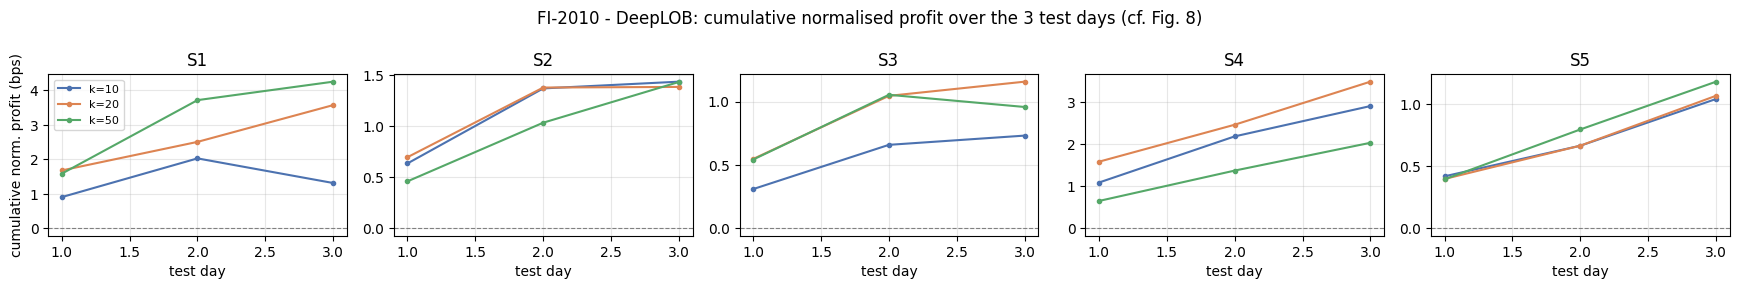

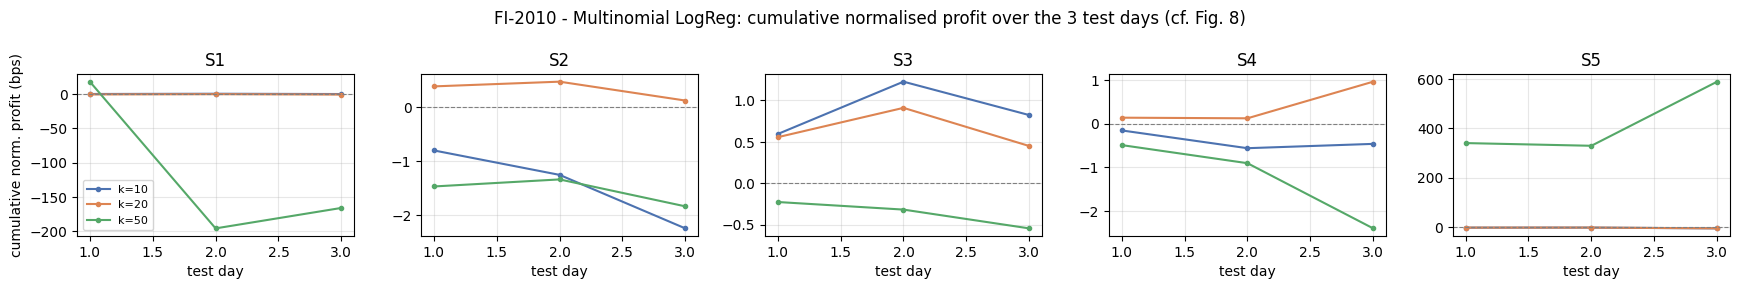

In [27]:
for model in ["DeepLOB", "Multinomial LogReg"]:
    plot_cumulative_profits(df_fi_trade, model, FI_STOCKS, value="norm_bps", ylabel="cumulative norm. profit (bps)",
                            title=f"FI-2010 - {model}: cumulative normalised profit over the 3 test days (cf. Fig. 8)")

### 13.3 DeepLOB vs. the baseline, all stocks pooled
Boxplots of the 15 (stock, day) normalised profits per horizon and the pooled t-statistic.

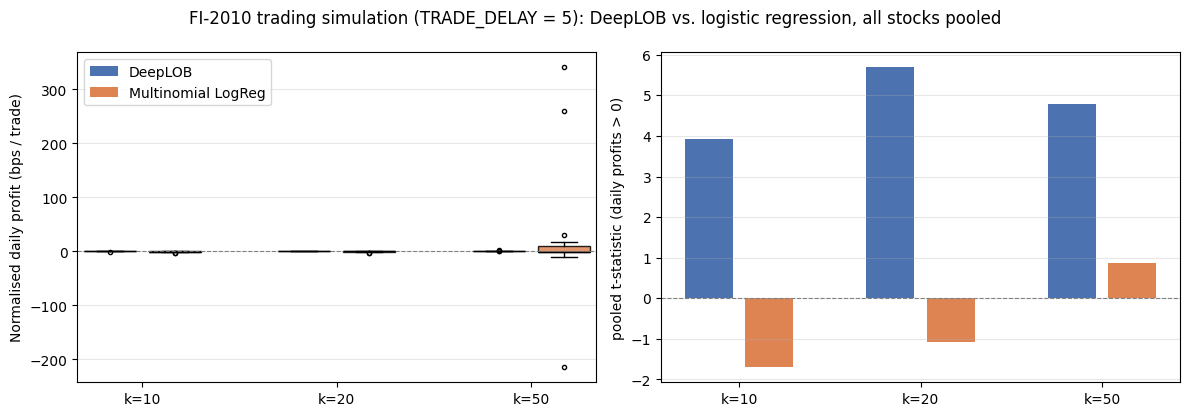

mean norm. profit (bps)  t-stat (daily)  trades/day  test accuracy
Model              k                                                                     
DeepLOB            10                   0.4961           3.914       603.5         0.8183
                   20                   0.7121           5.688       618.9         0.7292
                   50                   0.6578           4.779       691.5         0.7566
Multinomial LogReg 10                  -0.5025            -1.7       231.2         0.4695
                   20                  -0.3118          -1.072       264.1          0.397
                   50                    27.93          0.8641       194.1         0.3447

In [28]:
plot_pooled_comparison(df_fi_trade, value="norm_bps", ylabel="Normalised daily profit (bps / trade)",
                       title=f"FI-2010 trading simulation (TRADE_DELAY = {TRADE_DELAY}): DeepLOB vs. logistic regression, all stocks pooled")

# accuracy vs. money: the statistical and the economic view side by side
acc_vs_pnl = trading_summary(df_fi_trade, by=("Model", "k"), profit_col="norm_bps")[["Model", "k", "mean norm. profit (bps)", "t-stat (daily)", "trades/day"]].copy()
acc_vs_pnl["test accuracy"] = [accuracy_score(fi_true[r.k], FI_MODEL_PREDS[r.Model][r.k]) for r in acc_vs_pnl.itertuples()]
show_table(acc_vs_pnl.set_index(["Model", "k"]))

### 13.4 Sensitivity to the execution delay (extra)

The paper buys at *t + 5*, where one time-step is one **raw LOB event** (mean 0.19 s). One FI-2010 sample is a **block of 10 raw events**, so `TRADE_DELAY = 5`
samples is a *much* slower execution (≈ 50 events) than in the paper — and for k = 10 and 20 the horizon itself is only ~1–2 samples. The table and plot show how the pooled
profit depends on the delay: `0` = trade at the mid-price of the signal's own sample (an optimistic upper bound), `1` ≈ the paper's 5 raw events rounded up to the next FI-2010 sample.

Pooled mean normalised profit (bps / trade) by execution delay (FI-2010 samples)


delay                       0       1       2       5
Model              k                                 
DeepLOB            10 -0.3525  0.3338  0.5393  0.4961
                   20  0.2636   0.765  0.8242  0.7121
                   50  0.3393  0.5678  0.6308  0.6578
Multinomial LogReg 10   -1.26 -0.8253 -0.6426 -0.5025
                   20 -0.5807 -0.3491 -0.2985 -0.3118
                   50   27.56   27.59   27.63   27.93

Pooled t-statistic of the 15 daily profits by execution delay


delay                      0      1      2      5
Model              k                             
DeepLOB            10 -2.594  3.597  7.157  3.914
                   20 0.9437  4.038  6.016  5.688
                   50  2.199  4.732  5.866  4.779
Multinomial LogReg 10  -4.07 -2.819 -2.369   -1.7
                   20 -2.051 -1.174 -1.121 -1.072
                   50 0.8515 0.8515 0.8531 0.8641

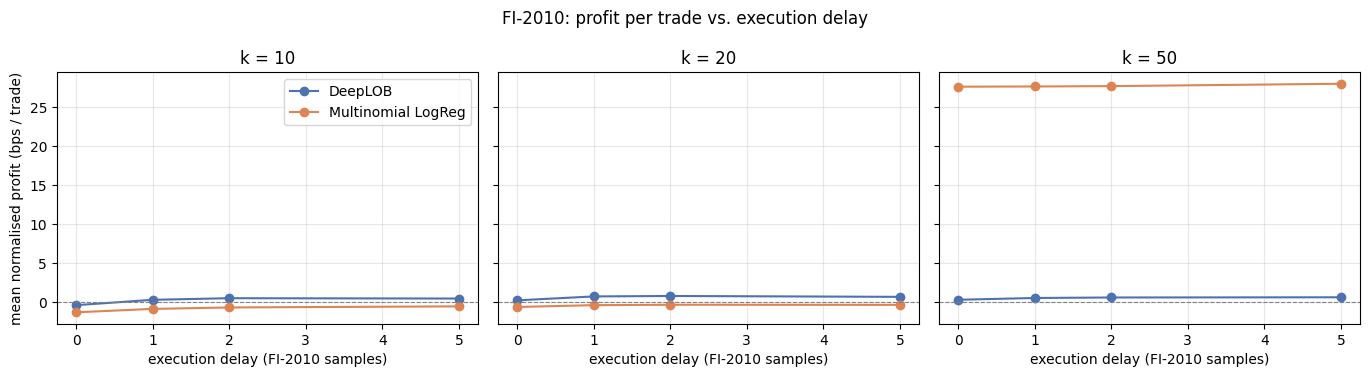

In [29]:
sens = []
for d in FI_SENSITIVITY_DELAYS:
    dd = run_fi_trading(FI_MODEL_PREDS, d)
    t = trading_summary(dd, by=("Model", "k"), profit_col="norm_bps")
    t["delay"] = d
    sens.append(t)
sens = pd.concat(sens)

print("Pooled mean normalised profit (bps / trade) by execution delay (FI-2010 samples)")
show_table(sens.pivot(index=["Model", "k"], columns="delay", values="mean norm. profit (bps)"))
print("Pooled t-statistic of the 15 daily profits by execution delay")
show_table(sens.pivot(index=["Model", "k"], columns="delay", values="t-stat (daily)"))

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(4.6 * len(HORIZONS), 3.8), sharey=True, squeeze=False)
for ax, k in zip(axes[0], HORIZONS):
    for m, c in [("DeepLOB", "#4C72B0"), ("Multinomial LogReg", "#DD8452")]:
        s_ = sens[(sens["k"] == k) & (sens["Model"] == m)].sort_values("delay")
        ax.plot(s_["delay"], s_["mean norm. profit (bps)"], marker="o", color=c, label=m)
    ax.axhline(0, color="gray", lw=0.8, ls="--"); ax.grid(alpha=0.3)
    ax.set_title(f"k = {k}"); ax.set_xlabel("execution delay (FI-2010 samples)")
axes[0, 0].set_ylabel("mean normalised profit (bps / trade)"); axes[0, 0].legend()
fig.suptitle("FI-2010: profit per trade vs. execution delay")
plt.tight_layout(); plt.show()

## Notes

- Set `QUICK_TEST = True` in the configuration cell (§2) to sanity-check the whole FI-2010 pipeline end-to-end on a tiny slice of data
  in a few minutes before committing to the full run.
- The full FI-2010 run now trains **three** DeepLOB models (k = 10, 20, 50), each up to 100 epochs with early stopping; budget ≈ 3× the time of the single-horizon
  version (on a Colab T4 roughly an hour or more per horizon, depending on when early stopping triggers). Predictions are cached in `fi_deeplob_k*.npz`, so a disconnect does not lose finished horizons
  (`REUSE_SAVED_FI = True`). The trading simulation itself takes seconds.
- All hyperparameters (`T=100`, batch size 32, Adam `lr=0.01, eps=1`, cross-entropy loss, early stopping
  patience 20) and the architecture (3 conv blocks → Inception → LSTM(64) → Dense(3)) follow the paper's
  text and figures directly; the only additions are gradient clipping (numerical stability at `lr=0.01`)
  and the engineering optimisations in Section 5/7, none of which change what the model learns.
- Test windows that reach across a day or stock boundary are still included in the FI-2010 classification metrics (as in the authors' reference code; they are < 1 % of the test set),
  but they are never traded.